# Cloud Cost Analytics Dashboard
Tools Used: Python, Pandas, Seaborn, Matplotlib  
Objective: Analyze cloud cost, usage, and SLA performance.

#1 COST OVERVIEW DASHBOARD           
The overall cloud cost shows a steady trend with noticeable fluctuations on certain days. These spikes indicate periods of higher resource consumption, likely driven by increased compute workloads or batch processing jobs. Continuous monitoring is required to control unexpected cost surges.

Index(['date', 'service', 'region_clean', 'cost_usd', 'usage_seconds'], dtype='object')


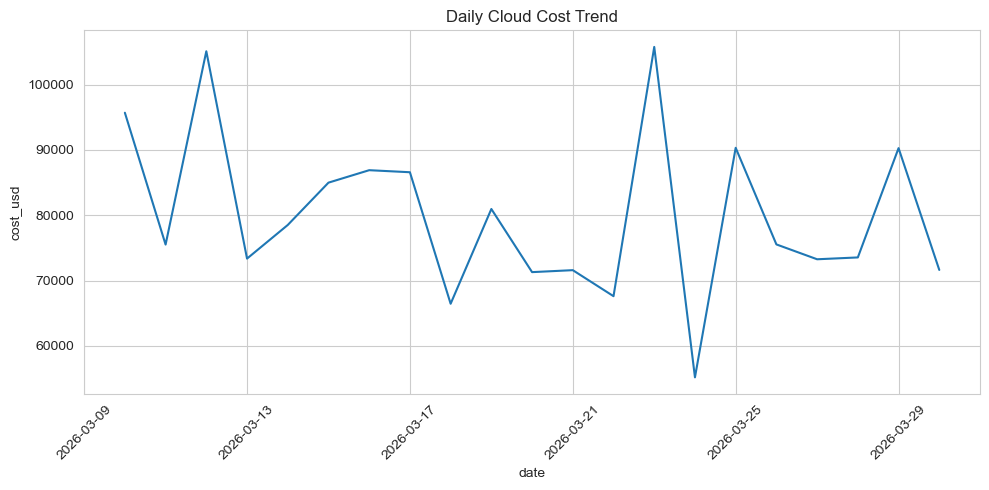

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('daily_cost_usage.csv', encoding='latin')

# Clean columns
df.columns = df.columns.str.strip().str.lower()

print(df.columns)  # 👈 always check once

# Fix datatypes
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['cost_usd'] = pd.to_numeric(df['cost_usd'], errors='coerce')

# Aggregate (important if multiple rows per date)
daily_cost = df.groupby('date')['cost_usd'].sum().reset_index()

# Plot
plt.figure(figsize=(10,5))
sns.lineplot(data=daily_cost, x='date', y='cost_usd')

plt.title("Daily Cloud Cost Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#2  DEPARTMENT CHARGEBACK DASHBOARD

A significant portion of the total cloud cost is concentrated in a few departments, indicating uneven resource consumption. Departments with higher costs should be analyzed further for optimization opportunities such as rightsizing or eliminating unused resources.

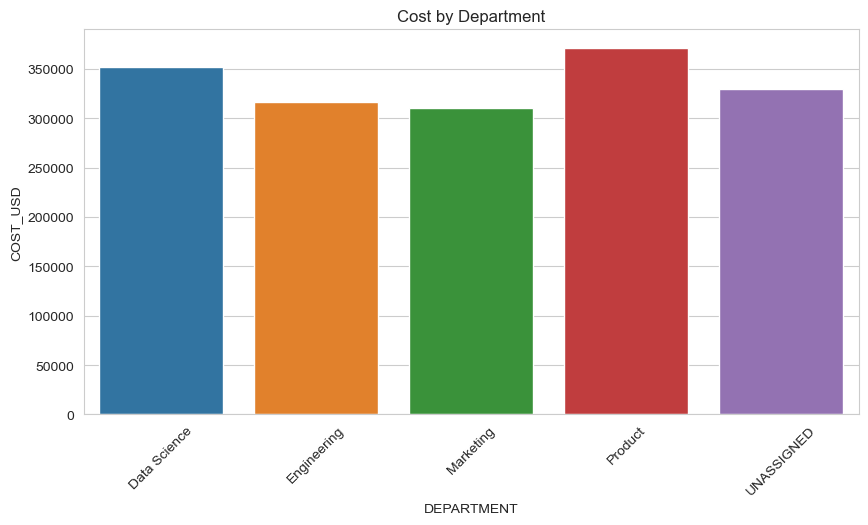

In [15]:
df = pd.read_csv("department_chargeback.csv")

plt.figure(figsize=(10,5))
sns.barplot(data=df, x='DEPARTMENT', y='COST_USD')
plt.title("Cost by Department")
plt.xticks(rotation=45)
plt.show()

In [14]:
print(df.columns)

Index(['DEPARTMENT', 'COST_USD'], dtype='object')


#3  REGION-WISE COST DASHBOARD

Certain regions contribute disproportionately to the overall cloud cost. This may be due to higher pricing, heavier workloads, or inefficient resource allocation. Optimizing workloads across regions or selecting cost-efficient regions can help reduce expenses.

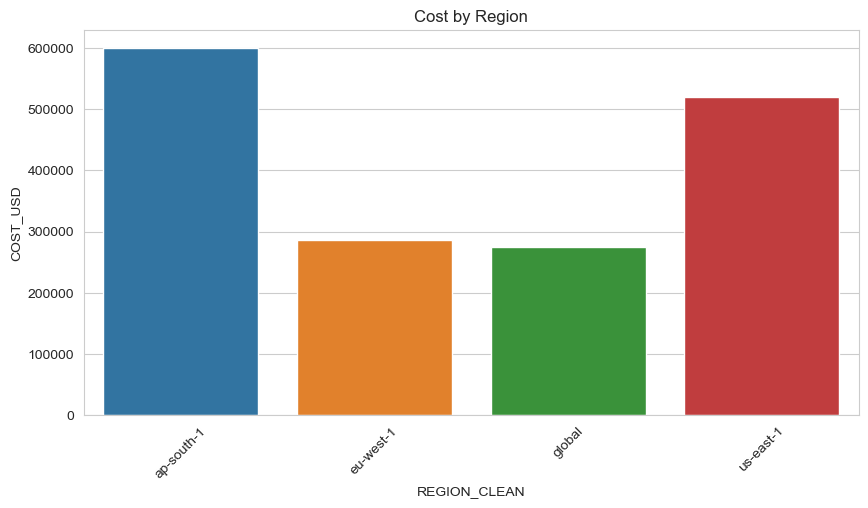

In [18]:
df = pd.read_csv("region_cost_summary.csv")

plt.figure(figsize=(10,5))
sns.barplot(data=df, x='REGION_CLEAN', y='COST_USD')
plt.title("Cost by Region")
plt.xticks(rotation=45)
plt.show()

In [17]:
print(df.columns)

Index(['REGION_CLEAN', 'COST_USD'], dtype='object')


#4 SLA & PERFORMANCE DASHBOARD

Most services meet the expected SLA targets, indicating stable system performance. However, a few services fall below the threshold, highlighting potential reliability issues that require immediate attention to avoid service disruptions.

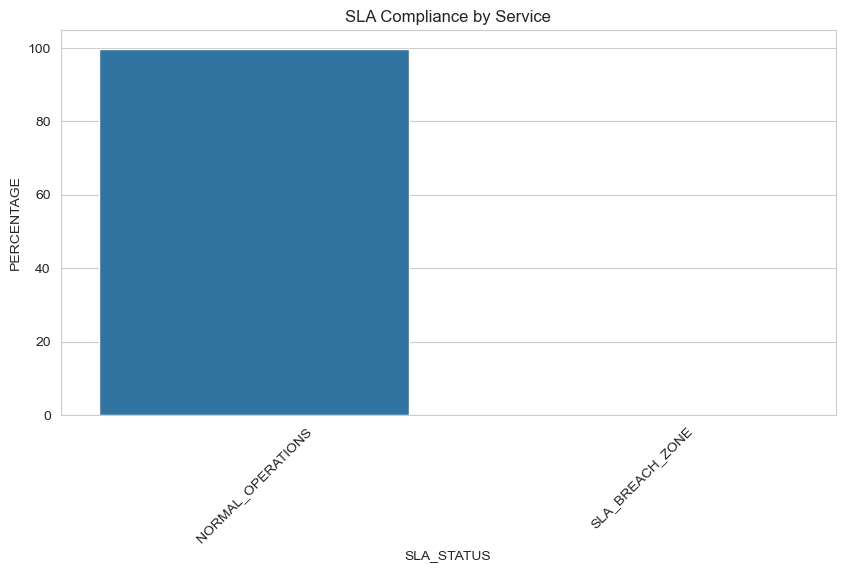

In [21]:
df = pd.read_csv("sla_kpi.csv")

plt.figure(figsize=(10,5))
sns.barplot(data=df, x='SLA_STATUS', y='PERCENTAGE')
plt.title("SLA Compliance by Service")
plt.xticks(rotation=45)
plt.show()

In [20]:
print(df.columns)

Index(['SLA_STATUS', 'PERCENTAGE'], dtype='object')


#5 USAGE VS COST ANALYSIS (ADVANCED)

There is a clear positive correlation between resource usage and cost, as expected. However, some outliers indicate disproportionately high costs for relatively low usage, suggesting inefficiencies such as over-provisioned resources or pricing anomalies.

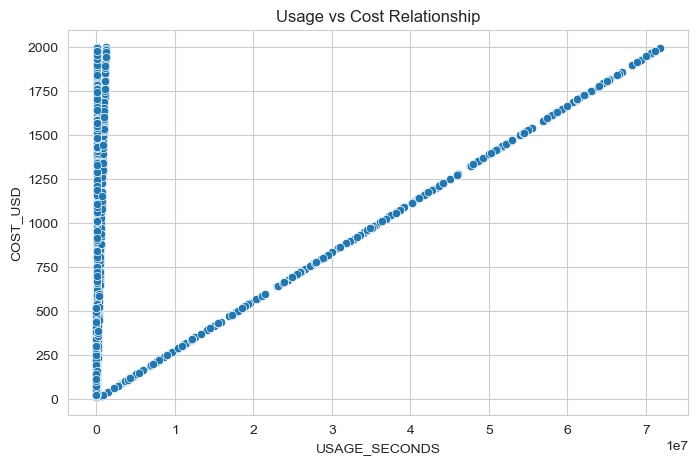

In [24]:
df = pd.read_csv("master_cleaned_cloud_data.csv")

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='USAGE_SECONDS', y='COST_USD')
plt.title("Usage vs Cost Relationship")
plt.show()

In [23]:
print(df.columns)

Index(['USAGE_ID', 'ACCOUNT', 'DEPARTMENT', 'TS_SYNCHRONIZED', 'SERVICE',
       'SKU', 'USAGE_SECONDS', 'COST_USD', 'REGION_CLEAN', 'SLA_STATUS',
       'TICKET_ID'],
      dtype='object')


7 ANOMALY DETECTION

The analysis highlights sudden spikes in cloud spending that deviate significantly from normal patterns. These anomalies may be caused by unexpected workloads, configuration issues, or billing errors and should be investigated promptly.

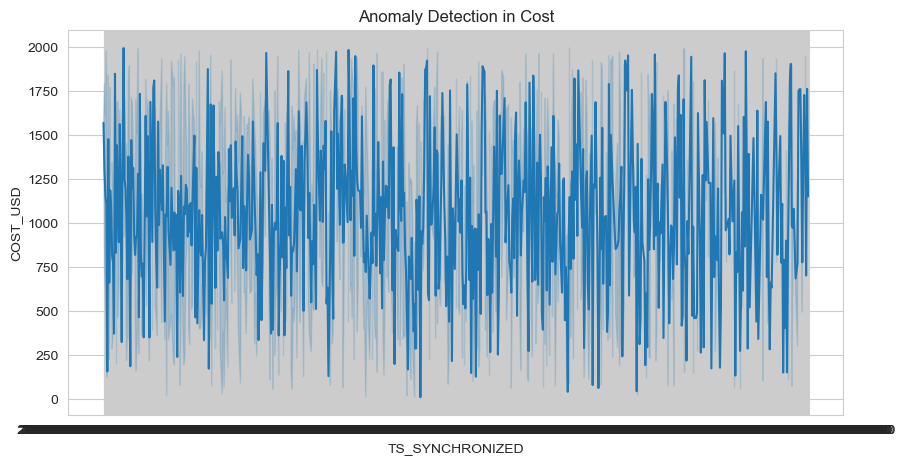

In [28]:
df['z_score'] = (df['COST_USD'] - df['COST_USD'].mean()) / df['COST_USD'].std()
anomalies = df[df['z_score'] > 3]

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='TS_SYNCHRONIZED', y='COST_USD')
sns.scatterplot(data=anomalies, x='TS_SYNCHRONIZED', y='COST_USD')
plt.title("Anomaly Detection in Cost")
plt.show()